In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.dates as mdates
import pandas as pd

In [5]:
dataSet1 = pd.read_csv("../data/Electronic_sales_Setp2023_sept2024.csv", sep=",", index_col=0)
dataSet1

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19995,19996,27,Female,No,Smartphone,SMP234,4,Completed,Bank Transfer,6838.08,1139.68,6,2024-06-15,Expedited,NaN,0.00
19996,19996,27,Female,Yes,Laptop,LTP123,4,Abandoned cart,Credit Card,2697.28,674.32,4,2024-07-18,Standard,NaN,0.00
19997,19996,27,Female,No,Headphones,HDP456,4,Completed,Bank Transfer,1805.90,361.18,5,2024-08-26,Standard,"Impulse Item, Extended Warranty, Accessory",198.98
19998,19997,27,Male,No,Headphones,HDP456,1,Cancelled,Bank Transfer,2528.26,361.18,7,2024-01-06,Expedited,"Extended Warranty, Accessory",101.34


In [ ]:
dataSet1.info()

<class 'pandas.core.frame.DataFrame'>
Index: 20000 entries, 0 to 19999
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer ID        20000 non-null  int64  
 1   Age                20000 non-null  int64  
 2   Gender             19999 non-null  object 
 3   Loyalty Member     20000 non-null  object 
 4   Product Type       20000 non-null  object 
 5   SKU                20000 non-null  object 
 6   Rating             20000 non-null  int64  
 7   Order Status       20000 non-null  object 
 8   Payment Method     20000 non-null  object 
 9   Total Price        20000 non-null  float64
 10  Unit Price         20000 non-null  float64
 11  Quantity           20000 non-null  int64  
 12  Purchase Date      20000 non-null  object 
 13  Shipping Type      20000 non-null  object 
 14  Add-ons Purchased  15132 non-null  object 
 15  Add-on Total       20000 non-null  float64
dtypes: float64(3), int64(4), ob

In [6]:
dataSetHpy1a = dataSet1[dataSet1['Unit Price'].notna() & (dataSet1['Unit Price'] > 0)]
dataSetHpy1a = dataSetHpy1a.groupby(['SKU'], as_index=False)['Unit Price'].max()
dataSetHpy1a = dataSetHpy1a.sort_values(by='Unit Price', ascending=False)


In [7]:
dataSetHpy1b = dataSet1[dataSet1['Unit Price'].notna() & (dataSet1['Unit Price'] > 0)]
dataSetHpy1b = dataSetHpy1b.groupby(['SKU'], as_index=False)['Rating'].mean()
dataSetHpy1b = dataSetHpy1b.sort_values(by='Rating', ascending=False)
         

In [8]:
# Unimos ambos dataframes por SKU
dataSetHpy1 = pd.merge(
    dataSetHpy1a[['SKU', 'Unit Price']], 
    dataSetHpy1b[['SKU', 'Rating']], 
    on='SKU', 
    how='inner'
)

# Mostramos el resultado ordenado por precio
dataSetHpy1 = dataSetHpy1.sort_values(by='Unit Price', ascending=False)


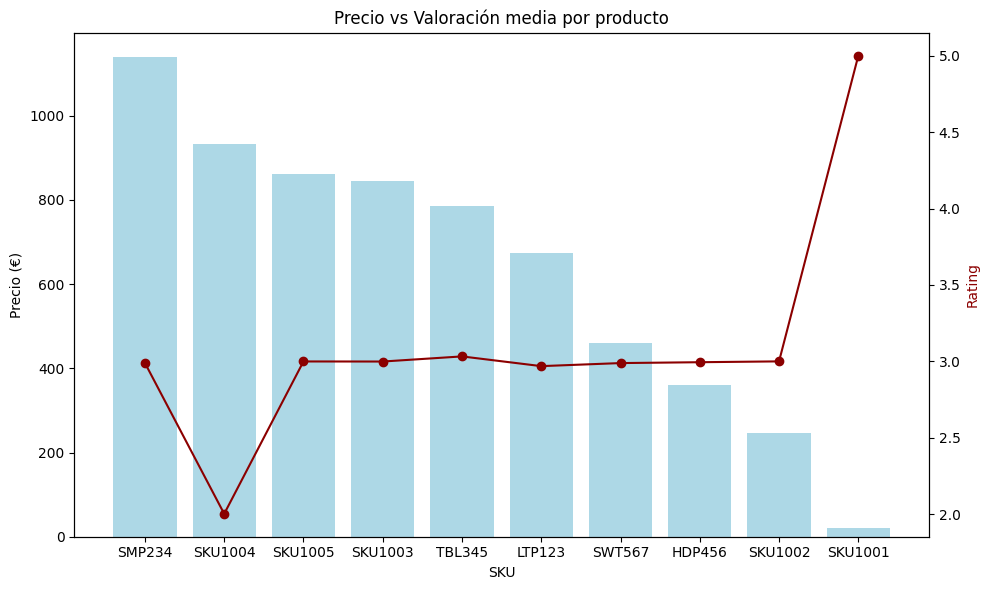

In [9]:
fig, ax1 = plt.subplots(figsize=(10,6))

ax2 = ax1.twinx()
ax1.bar(dataSetHpy1['SKU'], dataSetHpy1['Unit Price'], color='lightblue', label='Precio (€)')
ax2.plot(dataSetHpy1['SKU'], dataSetHpy1['Rating'], color='darkred', marker='o', label='Rating')

ax1.set_xlabel('SKU')
ax1.set_ylabel('Precio (€)')
ax2.set_ylabel('Rating', color='darkred')
plt.title("Precio vs Valoración media por producto")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Hipótesis 2

#### Los jóvenes hacen más pedidos de productos baratos

In [10]:
# Eliminamos registros con edades o precios nulos
dataSetHpy2 = dataSet1.copy()
# Definimos rangos de edad
bins = [0, 29, 59, 120]
labels = ['Joven', 'Adulto', 'Mayor']
dataSetHpy2['AgeGroup'] = pd.cut(dataSetHpy2['Age'], bins=bins, labels=labels, right=True)

# Calculamos el precio medio por grupo de edad
#dataSetHpy2 = dataSetHpy2.groupby('AgeGroup', as_index=False)['Unit Price'].mean()
dataSetHpy2 = dataSetHpy2.sort_values(by='AgeGroup', ascending=False)


C:\Users\migel\AppData\Local\Temp\ipykernel_15560\3034812723.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


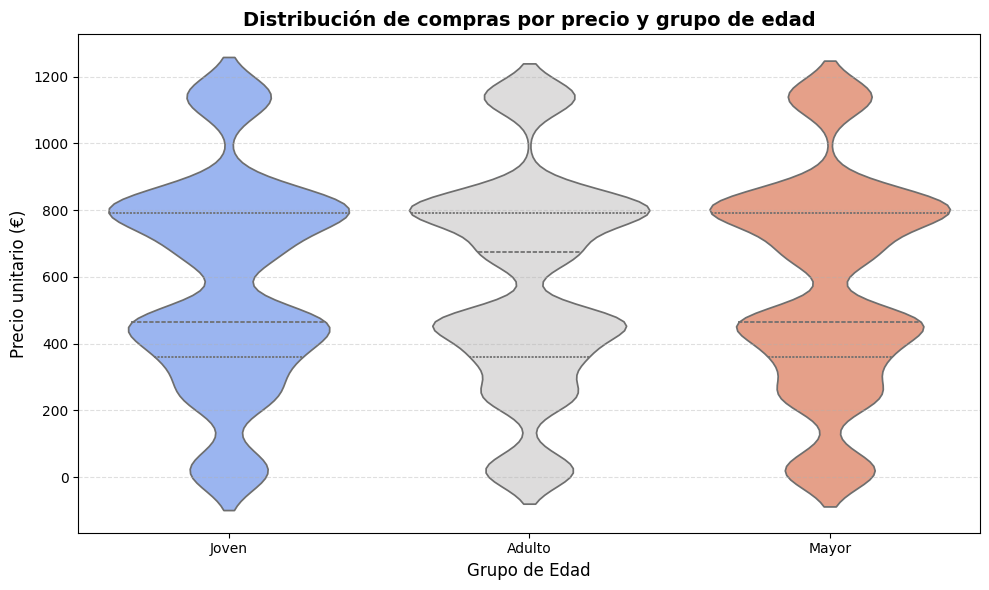

In [11]:
plt.figure(figsize=(10,6))

sns.violinplot(
    data=dataSetHpy2,  # aquí usaremos el DataFrame original con todas las compras, no agrupadas
    x='AgeGroup',
    y='Unit Price',
    palette='coolwarm',
    inner='quartile'   # dibuja los cuartiles dentro del violín
)

plt.title('Distribución de compras por precio y grupo de edad', fontsize=14, weight='bold')
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Precio unitario (€)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

C:\Users\migel\AppData\Local\Temp\ipykernel_15560\2731887064.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


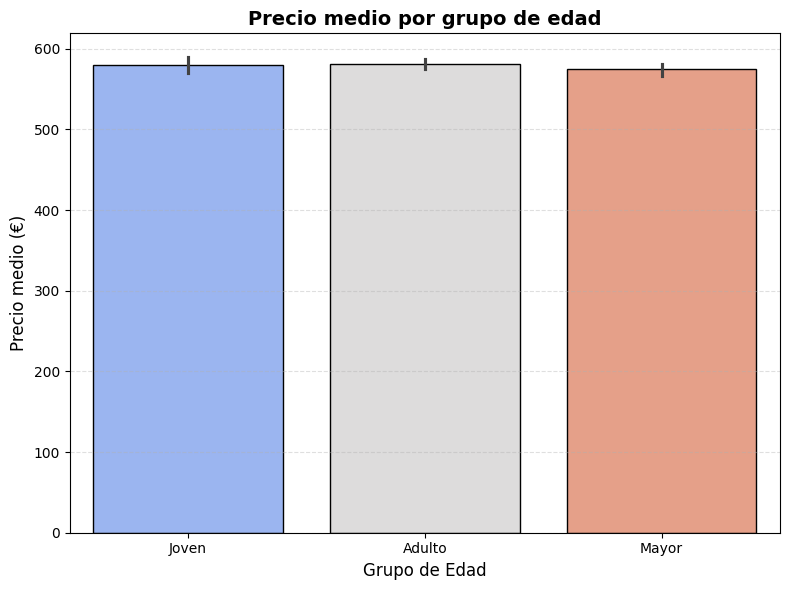

In [12]:
plt.figure(figsize=(8,6))

sns.barplot(
    data=dataSetHpy2,
    x='AgeGroup',
    y='Unit Price',
    palette='coolwarm',
    edgecolor='black'
)

plt.title('Precio medio por grupo de edad', fontsize=14, weight='bold')
plt.xlabel('Grupo de Edad', fontsize=12)
plt.ylabel('Precio medio (€)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

<Axes: xlabel='Unit Price', ylabel='Count'>

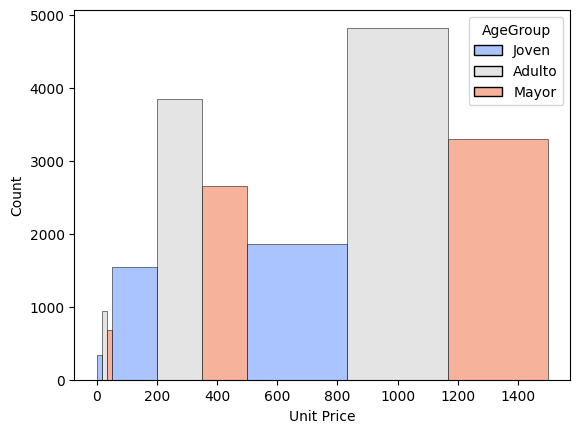

In [19]:
binsprecios = [0, 50, 500, 1500]  # rangos de precio
sns.histplot(
    data=dataSetHpy2,
    x='Unit Price',
    hue='AgeGroup',
    bins=binsprecios,
    multiple='dodge',
    palette='coolwarm',
    edgecolor='black'
)

# HIPÓTESIS 3
### Los clientes fidelizados suman una suma de precio de pedidos totales mayor a la suma del precio de pedidos de clientes no fidelizados

C:\Users\migel\AppData\Local\Temp\ipykernel_20924\3264302463.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  dataSetHpy3 = dataSetHpy3[dataSet1['Total Price'].notna() & dataSet1['Purchase Date'].notna()]


<Figure size 1100x600 with 0 Axes>

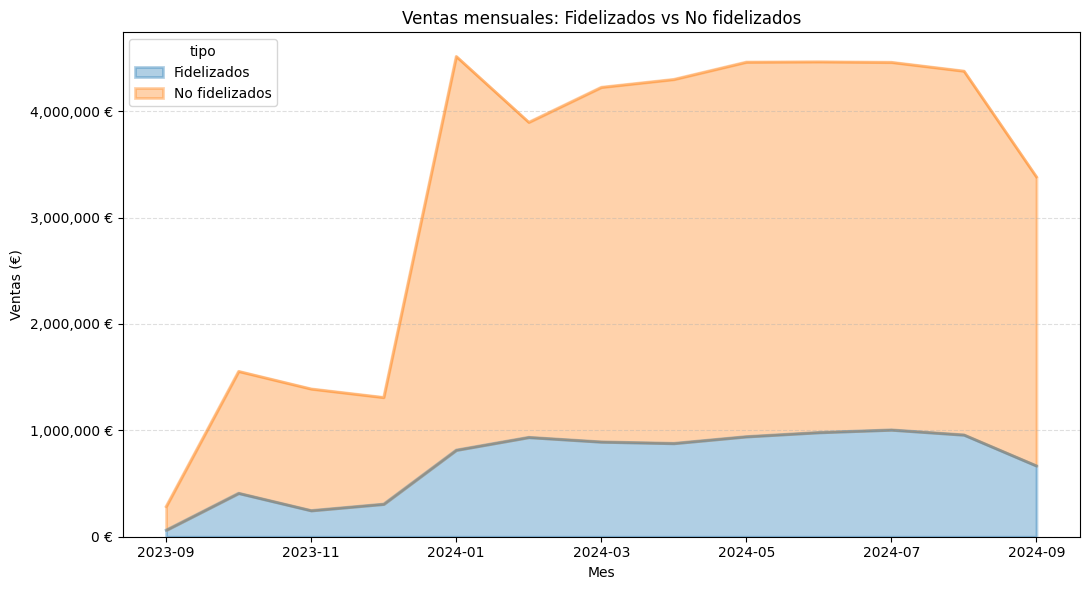

In [126]:
dataSetHpy3 = dataSet1.loc[dataSet1["Order Status"] == "Completed"]
dataSetHpy3 = dataSetHpy3[dataSet1['Total Price'].notna() & dataSet1['Purchase Date'].notna()]
dataSetHpy3['Purchase Date'] = pd.to_datetime(dataSetHpy3['Purchase Date'])

# Creamos una columna de mes (año-mes)
dataSetHpy3['Month'] = dataSetHpy3['Purchase Date'].dt.to_period('M').astype(str)

# Agrupamos por mes y fidelización, sumando el total de ventas
sales_by_month = (
    dataSetHpy3
    .groupby(['Month', 'Loyalty Member'], as_index=False)['Total Price']
    .sum()
    .sort_values('Month')
)

hp3ComprasFieles = sales_by_month[sales_by_month["Loyalty Member"] == "Yes"][["Month", "Total Price"]]
hp3ComprasNoFieles = sales_by_month[sales_by_month["Loyalty Member"] == "No"][["Month", "Total Price"]]


# Añadimos una columna que indique el tipo de cliente
hp3ComprasFieles['tipo'] = 'Fidelizados'
hp3ComprasNoFieles['tipo'] = 'No fidelizados'

# Unimos ambos dataframes
df_total = pd.concat([hp3ComprasFieles, hp3ComprasNoFieles])

df_pivot = df_total.pivot_table(
    index='Month',
    columns='tipo',
    values='Total Price',
    aggfunc='sum'
).sort_index()


plt.figure(figsize=(11,6))
ax = df_pivot.plot.area(alpha=0.35, linewidth=2, figsize=(11,6))
ax.yaxis.set_major_formatter(mtick.StrMethodFormatter('{x:,.0f} €'))


# Mejoras estéticas
ax.set_title('Ventas mensuales: Fidelizados vs No fidelizados', fontsize=12)
ax.set_xlabel('Mes')
ax.set_ylabel('Ventas (€)')
#plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# Hipótesis 4

#### ¿Los clientes fidelizados tienen una tasa de abandono de carritos menor que los clientes no fidelizados?

In [127]:
# 1. Filtramos solo carritos abandonados
abandoned = dataSet1[dataSet1['Order Status'] == "Abandoned cart"].copy()

# 2. Nos aseguramos de tener la fecha como datetime
abandoned['Purchase Date'] = pd.to_datetime(abandoned['Purchase Date'])

# 3. Creamos columna de mes para agrupar
abandoned['Month'] = abandoned['Purchase Date'].dt.to_period('M').astype(str)

# 4. Etiquetamos tipo de cliente
# Suponiendo que la columna que indica fidelización se llama 'Loyalty Member' y tiene 'Yes'/'No'
abandoned['tipo'] = abandoned['Loyalty Member'].map({'Yes':'Fidelizados', 'No':'No fidelizados'})

# 5. Contamos carritos abandonados por mes y tipo
abandoned_by_month = (
    abandoned.groupby(['Month','tipo'])
    .size()
    .reset_index(name='Abandoned Count')
    .sort_values('Month')
)


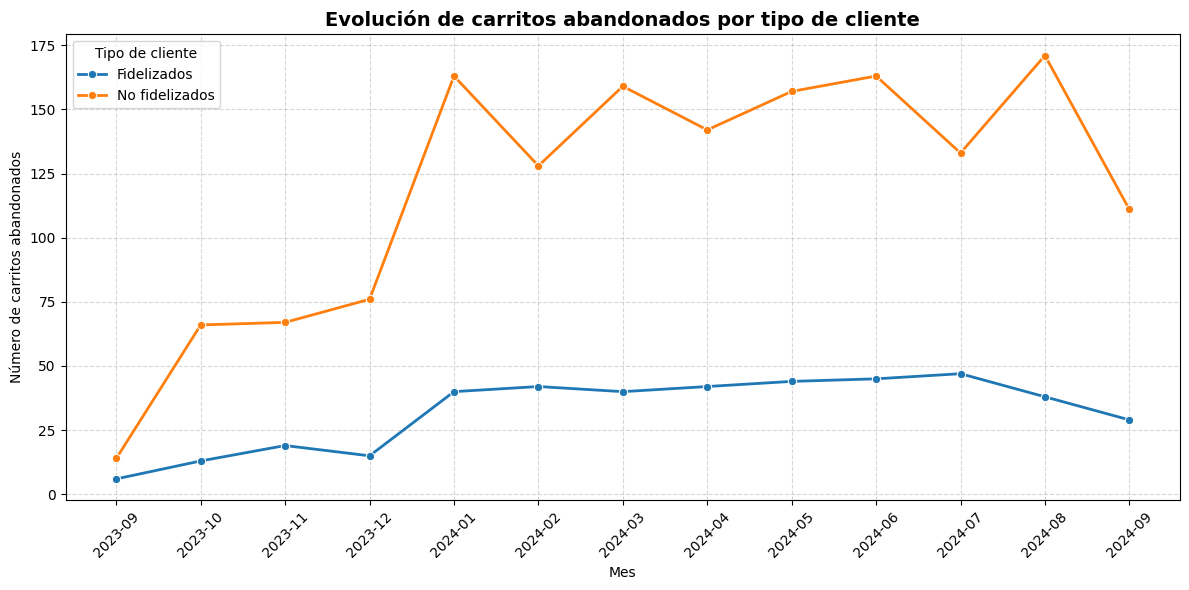

In [128]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=abandoned_by_month,
    x='Month',
    y='Abandoned Count',
    hue='tipo',
    marker='o',
    lw=2
)

plt.title('Evolución de carritos abandonados por tipo de cliente', fontsize=14, weight='bold')
plt.xlabel('Mes')
plt.ylabel('Número de carritos abandonados')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Tipo de cliente')
plt.tight_layout()
plt.show()

# Hipótesis 5

#### Los clientes fidelizados completan más compras y cancelan menos pedidos.

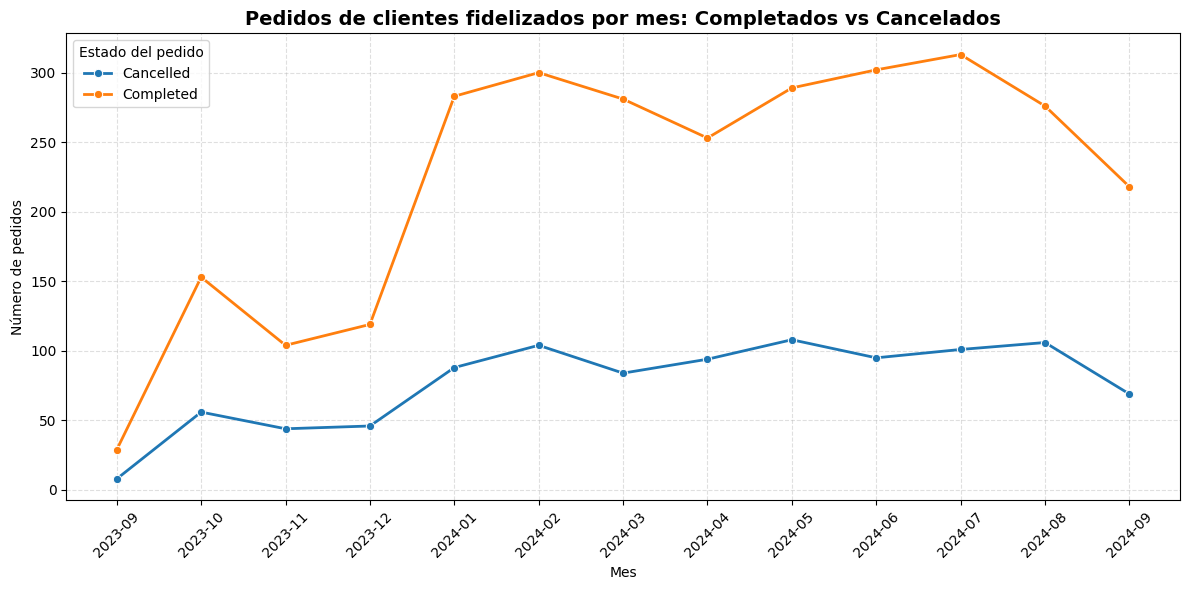

In [131]:

# Filtramos solo clientes fidelizados
fidelizados = dataSet1[dataSet1['Loyalty Member'] == 'Yes'].copy()
fidelizados['Purchase Date'] = pd.to_datetime(fidelizados['Purchase Date'])
fidelizados['Month'] = fidelizados['Purchase Date'].dt.to_period('M').astype(str)

# Solo Completed y Canceled
fidelizados_status = fidelizados[fidelizados['Order Status'].isin(['Completed', 'Cancelled'])]

# Contamos pedidos por mes y estado
pedidos_por_mes = (
    fidelizados_status.groupby(['Month','Order Status'])
    .size()
    .reset_index(name='Count')
)

# --- Gráfico de líneas comparando Completed y Canceled ---
plt.figure(figsize=(12,6))
sns.lineplot(
    data=pedidos_por_mes,
    x='Month',
    y='Count',
    hue='Order Status',
    marker='o',
    lw=2
)

plt.title('Pedidos de clientes fidelizados por mes: Completados vs Cancelados', fontsize=14, weight='bold')
plt.xlabel('Mes')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Estado del pedido')
plt.tight_layout()
plt.show()

# Hipótesis 6

##### ¿El miedo a gastar o el exceso de opciones son la nueva indecisión digital con un número de carritos abandonados mayor al 50%?

In [136]:
# Nos aseguramos de que la fecha es datetime
dataSet1['Purchase Date'] = pd.to_datetime(dataSet1['Purchase Date'])

# Creamos columna de mes
dataSet1['Month'] = dataSet1['Purchase Date'].dt.to_period('M').astype(str)

# Solo estados que nos interesan
estados = ['Completed', 'Cancelled', 'Abandoned cart']
pedidos = dataSet1[dataSet1['Order Status'].isin(estados)]

# Contamos pedidos por mes y estado
pedidos_por_mes = (
    pedidos.groupby(['Month','Order Status'])
    .size()
    .reset_index(name='Count')
)

# Rellenamos meses faltantes con 0 para cada estado
all_months = sorted(pedidos_por_mes['Month'].unique())
full_index = pd.DataFrame(list(itertools.product(all_months, estados)), columns=['Month','Order Status'])
pedidos_por_mes = full_index.merge(pedidos_por_mes, on=['Month','Order Status'], how='left')
pedidos_por_mes['Count'] = pedidos_por_mes['Count'].fillna(0)

# Pivotamos para tener columnas por estado
pedidos_pivot = pedidos_por_mes.pivot(index='Month', columns='Order Status', values='Count').fillna(0)

# Calculamos la tasa de abandono incluyendo cancelados y carritos
pedidos_pivot['Abandon_Rate'] = (pedidos_pivot['Cancelled'] + pedidos_pivot['Abandoned cart']) / (
    pedidos_pivot['Completed'] + pedidos_pivot['Cancelled'] + pedidos_pivot['Abandoned cart']
)

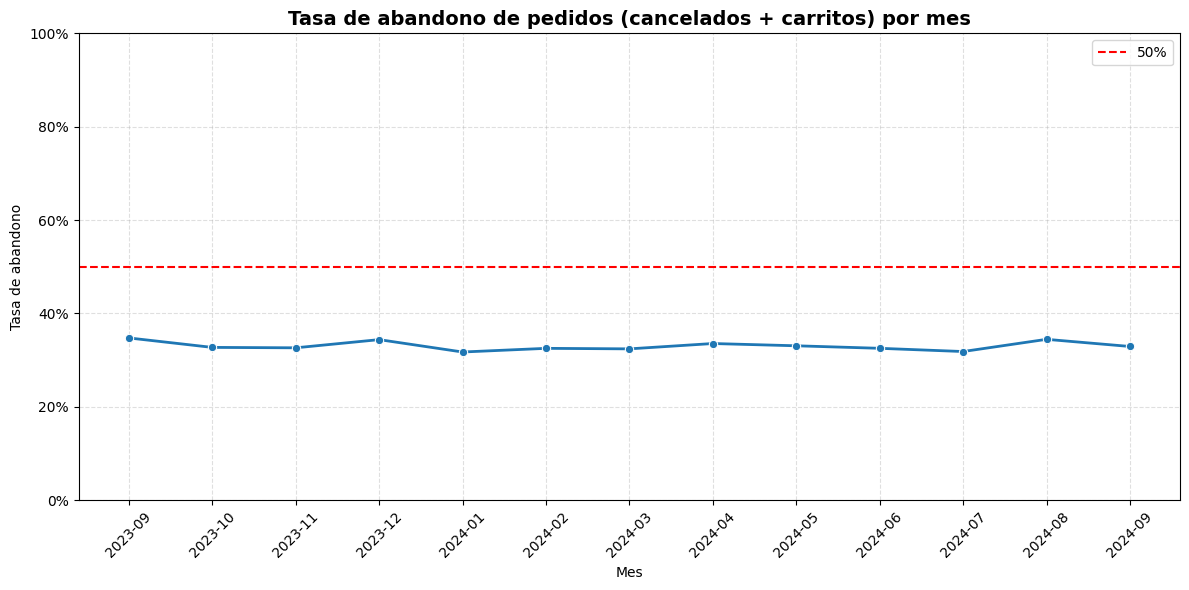

In [ ]:
plt.figure(figsize=(12,6))
sns.lineplot(
    data=pedidos_pivot.reset_index(),
    x='Month',
    y='Abandon_Rate',
    marker='o',
    lw=2
)

plt.axhline(0.5, color='red', linestyle='--', label='50%')
plt.title('Tasa de abandono de pedidos (cancelados + carritos abandonados) por mes', fontsize=14, weight='bold')
plt.ylabel('Tasa de abandono')
plt.xlabel('Mes')
plt.xticks(rotation=45)
plt.ylim(0,1)
plt.gca().yaxis.set_major_formatter(lambda y, _: f'{y:.0%}')  # Formato porcentaje
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

# Hipótesis 7
### ¿Han incrementado los pedidos con tipo de envío “Express” según avanzan los meses del año?

In [194]:

# Fecha como datetime
dataSet1['Purchase Date'] = pd.to_datetime(dataSet1['Purchase Date'])

# Columna de mes
dataSet1['Month'] = dataSet1['Purchase Date'].dt.to_period('M').astype(str)

filtered_df = dataSet1[dataSet1['Shipping Type'].isin(['Express', 'Standard', 'Same Day'])].copy()


# Contamos pedidos por mes y tipo de envío
orders_by_month = (
    filtered_df.groupby(['Month','Shipping Type'])
    .size()
    .reset_index(name='Count')
    .sort_values('Month')
)

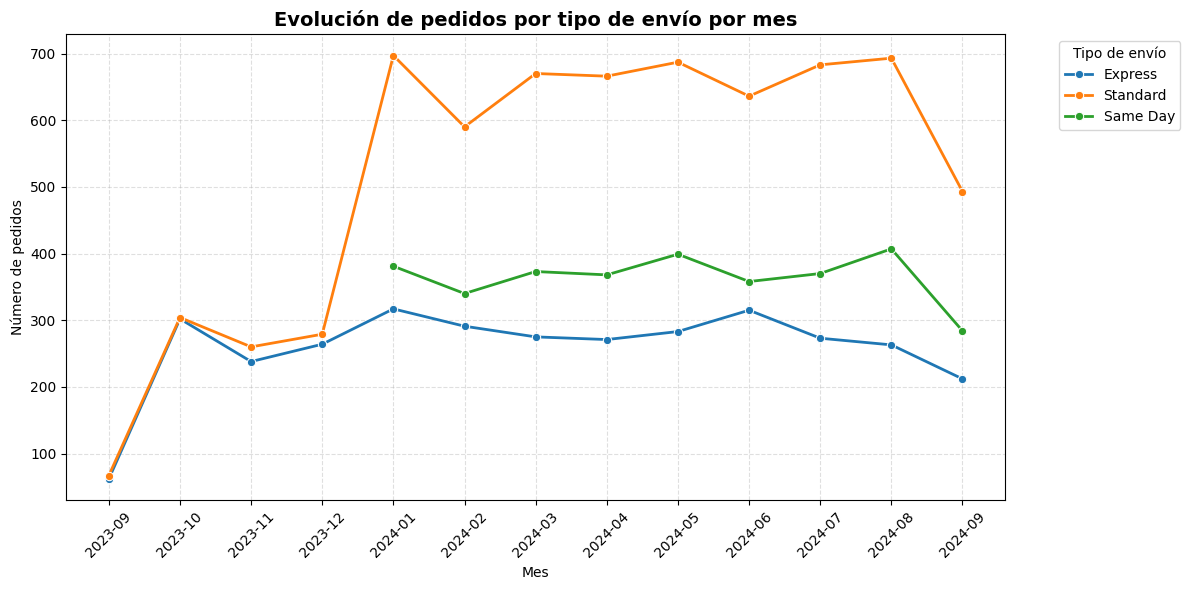

In [195]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=orders_by_month,
    x='Month',
    y='Count',
    hue='Shipping Type',
    marker='o',
    lw=2
)



plt.title('Evolución de pedidos por tipo de envío por mes', fontsize=14, weight='bold')
plt.xlabel('Mes')
plt.ylabel('Número de pedidos')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.4)
plt.legend(title='Tipo de envío', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()